# **Data Analytics Project** #

## **Raw Dataset Information**

| Column | Description |
| :--- | :--- |
| **Item_Identifier** | Product ID |
| **Item_Weight** | Weight of product |
| **Item_Fat_Content** | Content of product (`Low Fat` / `Regular`) |
| **Item_Visibility** | The percentage of all products in the store that are assigned to a specific product in the total display area |
| **Item_Type** | Category of product |
| **Item_MRP** | Maximum retail price of a product |
| **Outlet_Identifier** | Store ID |
| **Outlet_Establishment_Year** |  Year the store established |
| **Outlet_Size** | Size of the store |
| **Outlet_Location_Type** | The type of city where the store is located |
| **Outlet_Type** | Type of the store|
| **Item_Outlet_Sales** | Sales of product |

## **Setup and Configuration**

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from io import BytesIO
import base64

from sklearn.model_selection import train_test_split

In [5]:
import importlib.util

packages = ["catboost", "onnx"]

for pkg in packages:
    if importlib.util.find_spec(pkg) is None:
        !pip install {pkg}

## **Data Understanding**

To run this python notebook, please upload the two required files:
1. DA_raw.csv
2. template.html

which is available here:
https://drive.google.com/drive/folders/1bpDQMXB1f3cOIxOszqI_X3OIRzQU4nfj?usp=sharing

### **Data Loading**

In [6]:
df = pd.read_csv('DA_raw.csv')

#### Initial Data Profiling

In [7]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


### **Data Quality Check &  Basic EDA**

##### Check Dataset Structure

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


##### Check Dataset Decsriptive Statistics

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Item_Weight,7060.0,12.857645,4.643456,4.555,8.773750,12.600000,16.850000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290,834.247400,1794.331000,3101.296400,13086.964800


##### Check Missing Value

In [10]:
print('Ringkasan nilai null di DataFrame:')

null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({
    'Total Null': null_counts,
    'Persentase (%)': null_percentages
})
print(missing_data.sort_values(by='Persentase (%)', ascending=False))

Ringkasan nilai null di DataFrame:
                           Total Null  Persentase (%)
Outlet_Size                      2410       28.276428
Item_Weight                      1463       17.165317
Item_Fat_Content                    0        0.000000
Item_Identifier                     0        0.000000
Item_Visibility                     0        0.000000
Item_Type                           0        0.000000
Outlet_Identifier                   0        0.000000
Item_MRP                            0        0.000000
Outlet_Establishment_Year           0        0.000000
Outlet_Location_Type                0        0.000000
Outlet_Type                         0        0.000000
Item_Outlet_Sales                   0        0.000000


##### Check Zero Value

In [11]:
print((df['Item_Visibility'] == 0).sum())

526


##### Check Duplicate Value

In [12]:
duplicates = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicates}")

Jumlah data duplikat: 0


##### Check Consistency in Categorical Columns

In [13]:
categorical_cols = df.select_dtypes(include = 'object').columns.tolist()

for col in categorical_cols:
    print(df[col].value_counts())

Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dt

##### Check Outlier in Numerical Columns

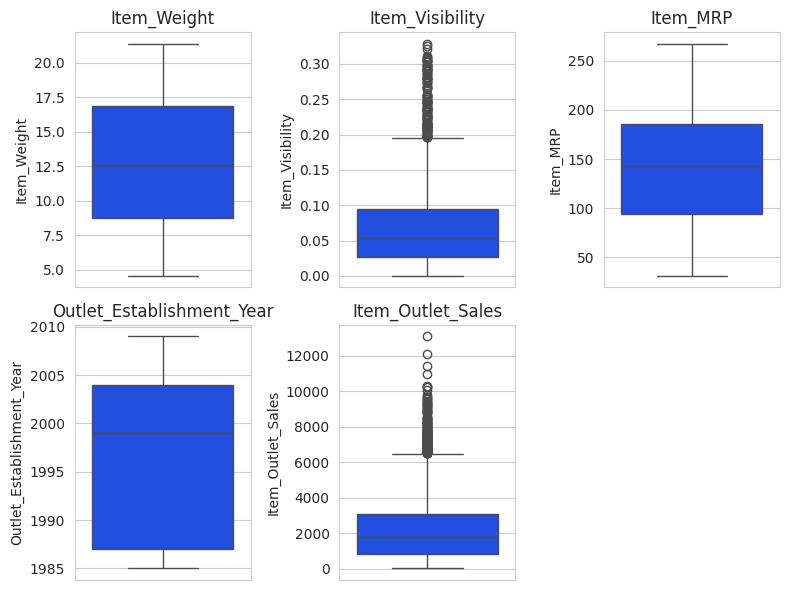

In [14]:
numerical_cols = df.select_dtypes(include =['int64', 'float64']).columns.tolist()

sns.set_style("whitegrid")
sns.set_palette("bright")

buf = BytesIO()
img_check_univariate_num_b64 = ""

def check_univariate_num(df, numCols):
    global img_check_univariate_num_b64
    n = len(numCols)
    rows = -(-n//3)
    plt.figure(figsize=(8,6))
    for i, col in enumerate(numCols, 1):
        plt.subplot(rows, 3, i)
        # contoh pake boxplot
        sns.boxplot(df[col])
        plt.title(col)
    plt.tight_layout()
    plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
    plt.show()
    img_check_univariate_num_b64 = 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()

check_univariate_num(df, numerical_cols)

In [15]:
outlier_summary = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Item_Weight': 0, 'Item_Visibility': 144, 'Item_MRP': 0, 'Outlet_Establishment_Year': 0, 'Item_Outlet_Sales': 186}


## **Data Preparation**

### **Target Binning**

In [16]:
def sales_category(x):
    if x < 1500:
        return 'Low'
    else:
        return 'High'

df_prep = df.copy()

# Ubah kolom Item_Outlet_Sales yang tadinya angka menjadi kategori teks ('Low', 'High')
df_prep['Item_Outlet_Sales'] = df_prep['Item_Outlet_Sales'].apply(sales_category)

### **Data Splitting**

In [17]:
X = df_prep.drop('Item_Outlet_Sales', axis=1)
y = df_prep['Item_Outlet_Sales']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (6818, 11)
X_test : (1705, 11)
y_train : (6818,)
y_test : (1705,)


### **Data Cleaning**

##### Handling Missing Values untuk X train



In [19]:
X_train['Item_Weight'] = X_train['Item_Weight'].fillna(X_train.groupby('Item_Identifier')['Item_Weight'].transform('mean'))
X_train['Item_Weight'] = X_train['Item_Weight'].fillna(X_train.groupby('Item_Type')['Item_Weight'].transform('mean'))

In [20]:
X_train['Item_Weight'] = X_train['Item_Weight'].fillna(X_train['Item_Weight'].mean())

In [21]:
mode_outlet = X_train.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=lambda x: x.mode().iloc[0])
X_train.loc[X_train['Outlet_Size'].isnull(), 'Outlet_Size'] = X_train.loc[X_train['Outlet_Size'].isnull(), 'Outlet_Type'].apply(lambda x: mode_outlet[x])

##### Handling Zero Values untuk X train

In [22]:
X_train['Item_Visibility'] = X_train['Item_Visibility'].replace(0, np.nan)
X_train['Item_Visibility'] = X_train['Item_Visibility'].fillna(X_train.groupby('Item_Type')['Item_Visibility'].transform('mean'))

##### Handling Inconsistencies untuk X train

In [23]:
X_train['Item_Fat_Content'] = X_train['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

X_train['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,4389
Regular,2429


##### Handling Missing Values untuk X test

In [24]:
X_test['Item_Weight'] = X_test['Item_Weight'].fillna(X_train.groupby('Item_Identifier')['Item_Weight'].transform('mean'))
X_test['Item_Weight'] = X_test['Item_Weight'].fillna(X_train.groupby('Item_Type')['Item_Weight'].transform('mean'))

In [25]:
X_test['Item_Weight'] = X_test['Item_Weight'].fillna(X_train['Item_Weight'].mean())

In [26]:
mode_outlet_train = X_train.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=lambda x: x.mode().iloc[0])
X_test.loc[X_test['Outlet_Size'].isnull(), 'Outlet_Size'] = X_test.loc[X_test['Outlet_Size'].isnull(), 'Outlet_Type'].apply(lambda x: mode_outlet_train[x])

##### Handling Zero Values untuk X test

In [27]:
X_test['Item_Visibility'] = X_test['Item_Visibility'].replace(0, np.nan)

# Hitung rata-rata Item_Visibility per Item_Type HANYA dari X_train (Biar aman dari leakage)
visibility_map = X_train.groupby('Item_Type')['Item_Visibility'].mean()

# Isi nilai NaN di X_test menggunakan kamus rata-rata dari X_train tadi
X_test['Item_Visibility'] = X_test['Item_Visibility'].fillna(X_test['Item_Type'].map(visibility_map))

# Jaga-jaga kalau masih ada sisa, isi dengan keseluruhan rata-rata X_train
X_test['Item_Visibility'] = X_test['Item_Visibility'].fillna(X_train['Item_Visibility'].mean())

##### Handling Inconsistencies untuk X test

In [28]:
X_test['Item_Fat_Content'] = X_test['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

X_test['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,1128
Regular,577


##### Missing Value After Cleaning untuk X train





In [29]:
print("Jumlah Missing Values setelah Cleaning di Train:")
print(X_train.isnull().sum())

Jumlah Missing Values setelah Cleaning di Train:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64


##### Missing Value After Cleaning untuk X test

In [30]:
print("Jumlah Missing Values setelah Cleaning di Test:")
print(X_test.isnull().sum())

Jumlah Missing Values setelah Cleaning di Test:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64


### **Data Transformation**

##### Feature Engineering untuk X train

In [31]:
X_train['Item_Category'] = X_train['Item_Identifier'].apply(lambda x: x[:2])
X_train['Item_Category'] = X_train['Item_Category'].map({
    'FD': 'Food',
    'DR': 'Drinks',
    'NC': 'Non-Consumable'
})

In [32]:
# Handling Inconsistencies utk Item Category
X_train.loc[X_train['Item_Category'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non-Edible'

In [33]:
X_train['Outlet_Years'] = 2013 - X_train['Outlet_Establishment_Year'] # karena dataset diambil di tahun 2013

##### Feature Engineering untuk X test

In [34]:
X_test['Item_Category'] = X_test['Item_Identifier'].apply(lambda x: x[:2])
X_test['Item_Category'] = X_test['Item_Category'].map({
    'FD': 'Food',
    'DR': 'Drinks',
    'NC': 'Non-Consumable'
})

In [35]:
# Handling Inconsistencies utk Item Category
X_test.loc[X_test['Item_Category'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non-Edible'

In [36]:
X_test['Outlet_Years'] = 2013 - X_test['Outlet_Establishment_Year'] # karena dataset diambil di tahun 2013

##### Check Feature Engineering

In [37]:
print("Label di Item_Category (Train):")
print(X_train['Item_Category'].unique())

print("\nLabel di Item_Category (Test):")
print(X_test['Item_Category'].unique())

Label di Item_Category (Train):
['Food' 'Non-Consumable' 'Drinks']

Label di Item_Category (Test):
['Food' 'Non-Consumable' 'Drinks']


In [38]:
print("Label di Item_Fat_Content (Train):")
print(X_train['Item_Fat_Content'].unique())

print("\nLabel di Item_Fat_Content (Test):")
print(X_test['Item_Fat_Content'].unique())

Label di Item_Fat_Content (Train):
['Regular' 'Non-Edible' 'Low Fat']

Label di Item_Fat_Content (Test):
['Low Fat' 'Non-Edible' 'Regular']


In [39]:
X_train[['Outlet_Years']].head()


,Outlet_Years
549,14
7757,11
764,16
6867,11
2716,16


In [40]:
X_test[['Outlet_Years']].head()

,Outlet_Years
7503,26
2957,16
7031,14
1084,28
856,9


##### Export Excel

In [41]:
X_train.to_csv('X_train_clean.csv', index=False)
X_test.to_csv('X_test_clean.csv', index=False)

### **EDA After Cleaning**

##### Descriptive Statistics

In [42]:
# df_prep.describe().T
X_train.describe().T
y_train.describe().T

,Item_Outlet_Sales
count,6818
unique,2
top,High
freq,3955



#### Visualisasi EDA

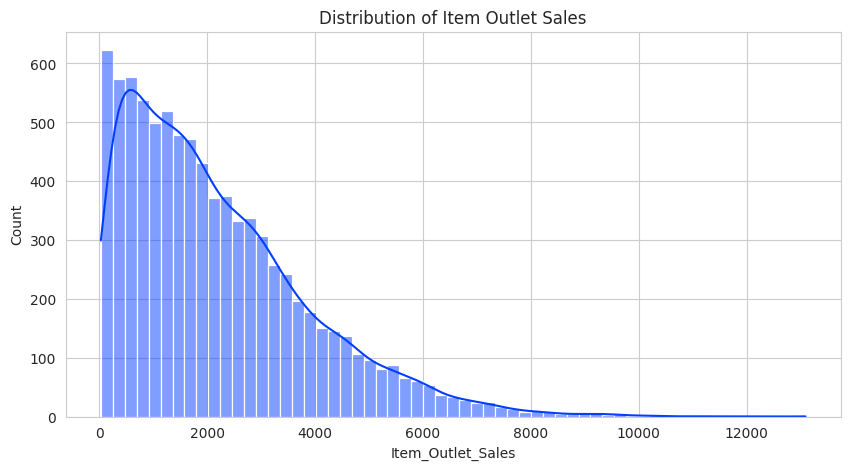

In [43]:
sns.set_style("whitegrid")
sns.set_palette("bright")

# --- PLOT 1: Histogram ---
plt.figure(figsize=(10, 5))
sns.histplot(df['Item_Outlet_Sales'], kde=True)
plt.title('Distribution of Item Outlet Sales')

buf = BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
plt.show()
img_histplot_item_outlet_sales_b64 = 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()


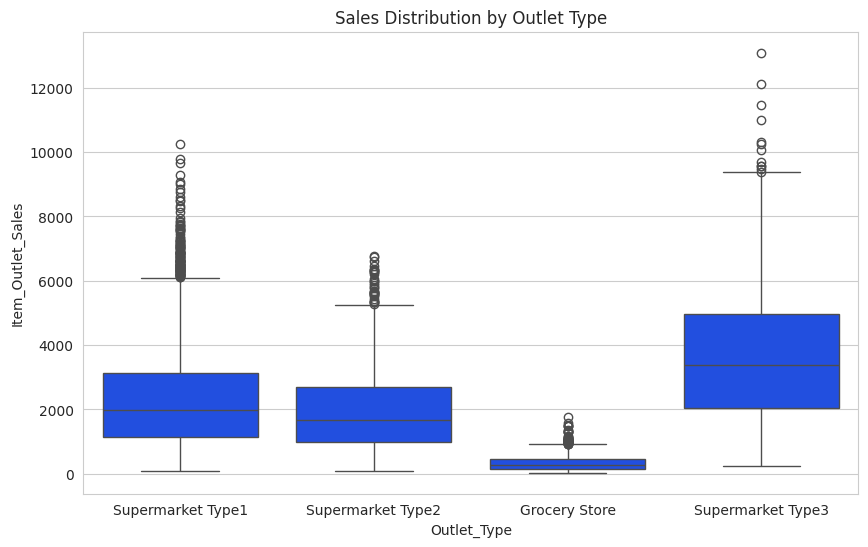

In [44]:
sns.set_style("whitegrid")
sns.set_palette("bright")

plt.figure(figsize=(10, 6))
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df)
plt.xticks(rotation=0)
plt.title('Sales Distribution by Outlet Type')

buf = BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
plt.show()
img_boxplot_item_outlet_sales_b64 = 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()


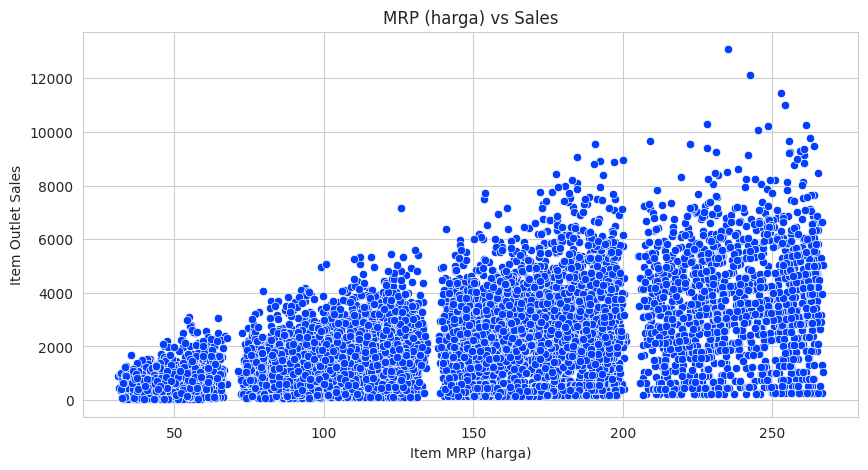

In [45]:
sns.set_style("whitegrid")
sns.set_palette("bright")

plt.figure(figsize=(10,5))

sns.scatterplot(
    x='Item_MRP',
    y='Item_Outlet_Sales',
    data=df,
)

plt.title('MRP (harga) vs Sales')
plt.xlabel('Item MRP (harga)')
plt.ylabel('Item Outlet Sales')

buf = BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
plt.show()
img_mrp_vs_sales_b64 = 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()

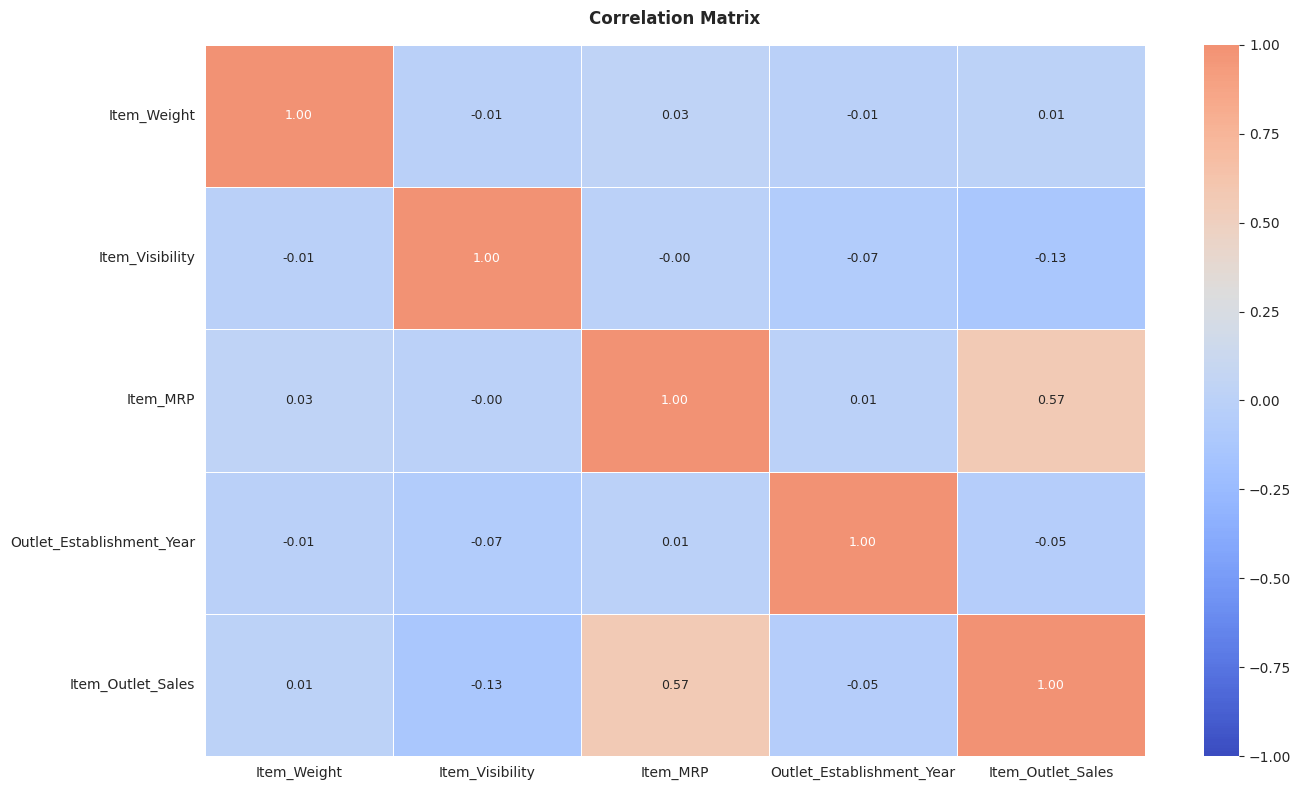

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")

corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0.3,
    linewidths=0.5,
    linecolor="white",
    fmt=".2f",
    annot_kws={"size": 9}
)
plt.title('Correlation Matrix', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix_coolwarm_fixed.png', dpi=150, bbox_inches='tight')

buf = BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
plt.show()
img_correlation_matrix_b64 = 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()

#### Uji Hipotesis Statistik (Chi-Square)

In [47]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Otomatis mengambil semua kolom yang tipe datanya teks/kategorikal di X_train
kolom_kategorikal = X_train.select_dtypes(include=['object', 'category']).columns

print(f"Menemukan {len(kolom_kategorikal)} kolom kategorikal untuk diuji: {list(kolom_kategorikal)}\n")
print("=" * 60)

# 2. Looping untuk menguji setiap kolom terhadap y_train
for kolom in kolom_kategorikal:
    print(f"\n▶️ UJI CHI-SQUARE UNTUK FITUR: {kolom}")
    print("=" * 40)

    # Membuat Tabel Kontingensi (Crosstab)
    contingency_table = pd.crosstab(X_train[kolom], y_train)

    print("TABEL KONTINGENSI:")
    print(contingency_table)
    print("-" * 40)

    # Menjalankan Uji Chi-Square
    chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)

    # Menampilkan Hasil Analisis Statistik
    print(f"Chi-Square Statistic : {chi2_stat:.4f}")
    print(f"P-Value              : {p_value:.4e}")  # Format eksponensial (e-05 artinya pangkat negatif)
    print(f"Degrees of Freedom   : {dof}")

    # Kesimpulan Otomatis berdasarkan Alpha (5%)
    alpha = 0.05
    if p_value < alpha:
        print("\n👉 KESIMPULAN: TOLAK H0 (SANGAT SIGNIFIKAN!)")
        print(f"Artinya, fitur '{kolom}' memengaruhi performa penjualan (High/Low) secara nyata.")
    else:
        print("\n👉 KESIMPULAN: GAGAL TOLAK H0 (TIDAK SIGNIFIKAN)")
        print(f"Artinya, tidak ada hubungan statistik yang kuat antara fitur '{kolom}' dengan performa penjualan.")

    print("=" * 60)

Menemukan 8 kolom kategorikal untuk diuji: ['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category']


▶️ UJI CHI-SQUARE UNTUK FITUR: Item_Identifier
TABEL KONTINGENSI:
Item_Outlet_Sales  High  Low
Item_Identifier             
DRA12                 1    3
DRA24                 3    3
DRA59                 3    4
DRB01                 2    1
DRB13                 3    2
...                 ...  ...
NCZ30                 4    2
NCZ41                 3    1
NCZ42                 2    1
NCZ53                 4    1
NCZ54                 5    1

[1555 rows x 2 columns]
----------------------------------------
Chi-Square Statistic : 2889.3273
P-Value              : 3.4603e-83
Degrees of Freedom   : 1554

👉 KESIMPULAN: TOLAK H0 (SANGAT SIGNIFIKAN!)
Artinya, fitur 'Item_Identifier' memengaruhi performa penjualan (High/Low) secara nyata.

▶️ UJI CHI-SQUARE UNTUK FITUR: Item_Fat_Content
TABEL KONTINGENSI:
Item

### **Drop Columns**

In [48]:
drop_cols = [
    'Item_Identifier', # tetep di drop krn resiko high cardinality dan overfitting
    'Outlet_Identifier', # tetep di drop krn resiko high cardinality dan overfitting
    'Outlet_Establishment_Year', # di drop krn udh ada outlet years
    # 'Item_Fat_Content', kalau di drop accuracy malah turun
]

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

### **Encoding - One Hot**

In [49]:
# Encode Train
X_train_encoded = pd.get_dummies(
    X_train,
    drop_first=True
)

# Encode Test
X_test_encoded = pd.get_dummies(
    X_test,
    drop_first=True
)

# Align (Memastikan jumlah kolom Train dan Test sama)
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

##### Save Train & Test Dataset

In [50]:
X_train_encoded.to_csv('X_train_encoded.csv', index=False)

X_test_encoded.to_csv('X_test_encoded.csv', index=False)

### **Scaling**

#### Fit Train

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)

#### Transform Test

In [52]:
X_test_scaled = scaler.transform(X_test_encoded)

## **Modelling**

#### CatBoost Regressor

In [53]:
#!pip install catboost

BEFORE SMOTE

In [54]:
print("--- DISTRIBUSI SEBELUM SMOTE ---")
print(y_train.value_counts())

--- DISTRIBUSI SEBELUM SMOTE ---
Item_Outlet_Sales
High    3955
Low     2863
Name: count, dtype: int64


SMOTE

In [55]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("--- DISTRIBUSI SETELAH SMOTE ---")
print(pd.Series(y_train_smote).value_counts())

--- DISTRIBUSI SETELAH SMOTE ---
Item_Outlet_Sales
High    3955
Low     3955
Name: count, dtype: int64


Library

In [56]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

CatBoost Baseline (default)

In [57]:
baseline_model = CatBoostClassifier(verbose=0, random_state=42)
baseline_model.fit(X_train_smote, y_train_smote)

# Prediksi menggunakan model baseline
y_pred_baseline = baseline_model.predict(X_test_scaled)

print("--- RECAP HASIL BASELINE ---")
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("\nClassification Report:\n", classification_report(y_test, y_pred_baseline))

--- RECAP HASIL BASELINE ---
Accuracy: 0.8252199413489736

Classification Report:
               precision    recall  f1-score   support

        High       0.81      0.89      0.85       947
         Low       0.84      0.75      0.79       758

    accuracy                           0.83      1705
   macro avg       0.83      0.82      0.82      1705
weighted avg       0.83      0.83      0.82      1705



Hyperparameter Tuning (Grid Search)

In [58]:
from sklearn.model_selection import GridSearchCV

# 1. Definisikan kombinasi parameter yang mau diuji
param_grid = {
    'iterations': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8]
}

# 2. Inisialisasi Grid Search (cv=3 agar proses running lebih cepat)
grid_search = GridSearchCV(
    estimator=CatBoostClassifier(verbose=0, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# 3. Latih Grid Search
print("Sedang cari parameter terbaik...")
grid_search.fit(X_train_smote, y_train_smote)

print("\n--- HASIL TUNING ---")
print("Parameter Terbaik:", grid_search.best_params_)

Sedang cari parameter terbaik...

--- HASIL TUNING ---
Parameter Terbaik: {'depth': 6, 'iterations': 100, 'learning_rate': 0.05}



CatBoost Tuning & Custom Threshold

In [59]:
# Ambil model terbaik hasil tuning
best_cat_model = grid_search.best_estimator_

# Ambil probabilitas kelas ke-0 ('High' secara alfabet)
y_pred_proba = best_cat_model.predict_proba(X_test_scaled)[:, 0]

# Set threshold baru
threshold = 0.49
cat_pred_custom = ["High" if prob >= threshold else "Low" for prob in y_pred_proba]

In [60]:
# Threshold check
cat_pred_default = best_cat_model.predict(X_test_scaled)

print("--- RECAP HASIL THRESHOLD DEFAULT ---")
print(accuracy_score(y_test, cat_pred_default))
print(classification_report(y_test, cat_pred_default))

--- RECAP HASIL THRESHOLD DEFAULT ---
0.8287390029325513
              precision    recall  f1-score   support

        High       0.82      0.89      0.85       947
         Low       0.85      0.75      0.80       758

    accuracy                           0.83      1705
   macro avg       0.83      0.82      0.82      1705
weighted avg       0.83      0.83      0.83      1705



CatBoost Final + Eval

In [61]:
print("--- RECAP HASIL MODEL FINAL ---")
print("CatBoost Accuracy :", accuracy_score(y_test, cat_pred_custom))
print("\nClassification Report:\n", classification_report(y_test, cat_pred_custom))

--- RECAP HASIL MODEL FINAL ---
CatBoost Accuracy : 0.8299120234604106

Classification Report:
               precision    recall  f1-score   support

        High       0.82      0.90      0.85       947
         Low       0.85      0.75      0.80       758

    accuracy                           0.83      1705
   macro avg       0.83      0.82      0.83      1705
weighted avg       0.83      0.83      0.83      1705



## **Evaluation**

Confusion Matrix

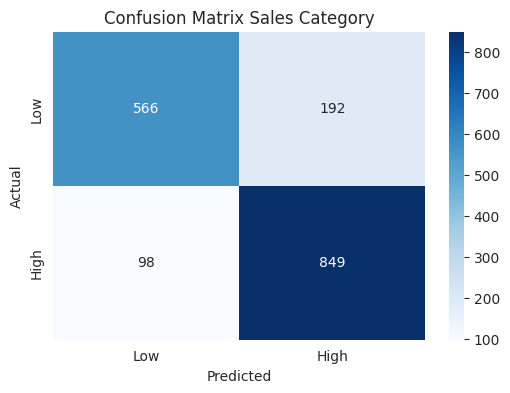

In [62]:
cm = confusion_matrix(y_test, cat_pred_custom, labels=['Low', 'High'])
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Sales Category')

buf = BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
plt.show()
img_confusion_matrix_sales_category_b64 = 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()

In [63]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Get probabilities for the positive class (assuming 'High' is the positive class)
y_pred_proba_positive = best_cat_model.predict_proba(X_test_scaled)[:, best_cat_model.classes_.tolist().index('High')]

# Convert y_test to binary (1 for 'High', 0 for 'Low')
y_test_binary = (y_test == 'High').astype(int)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test_binary, y_pred_proba_positive)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test_binary, y_pred_proba_positive)
avg_prec = average_precision_score(y_test_binary, y_pred_proba_positive)

# Feature Importance
feature_importances = best_cat_model.get_feature_importance()
feature_names = X_train_encoded.columns
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print(f"Calculated ROC AUC: {roc_auc:.3f}")
print(f"Calculated Average Precision: {avg_prec:.3f}")

Calculated ROC AUC: 0.905
Calculated Average Precision: 0.912


Akurasi Terdeteksi dari cat_pred_custom: 0.8299


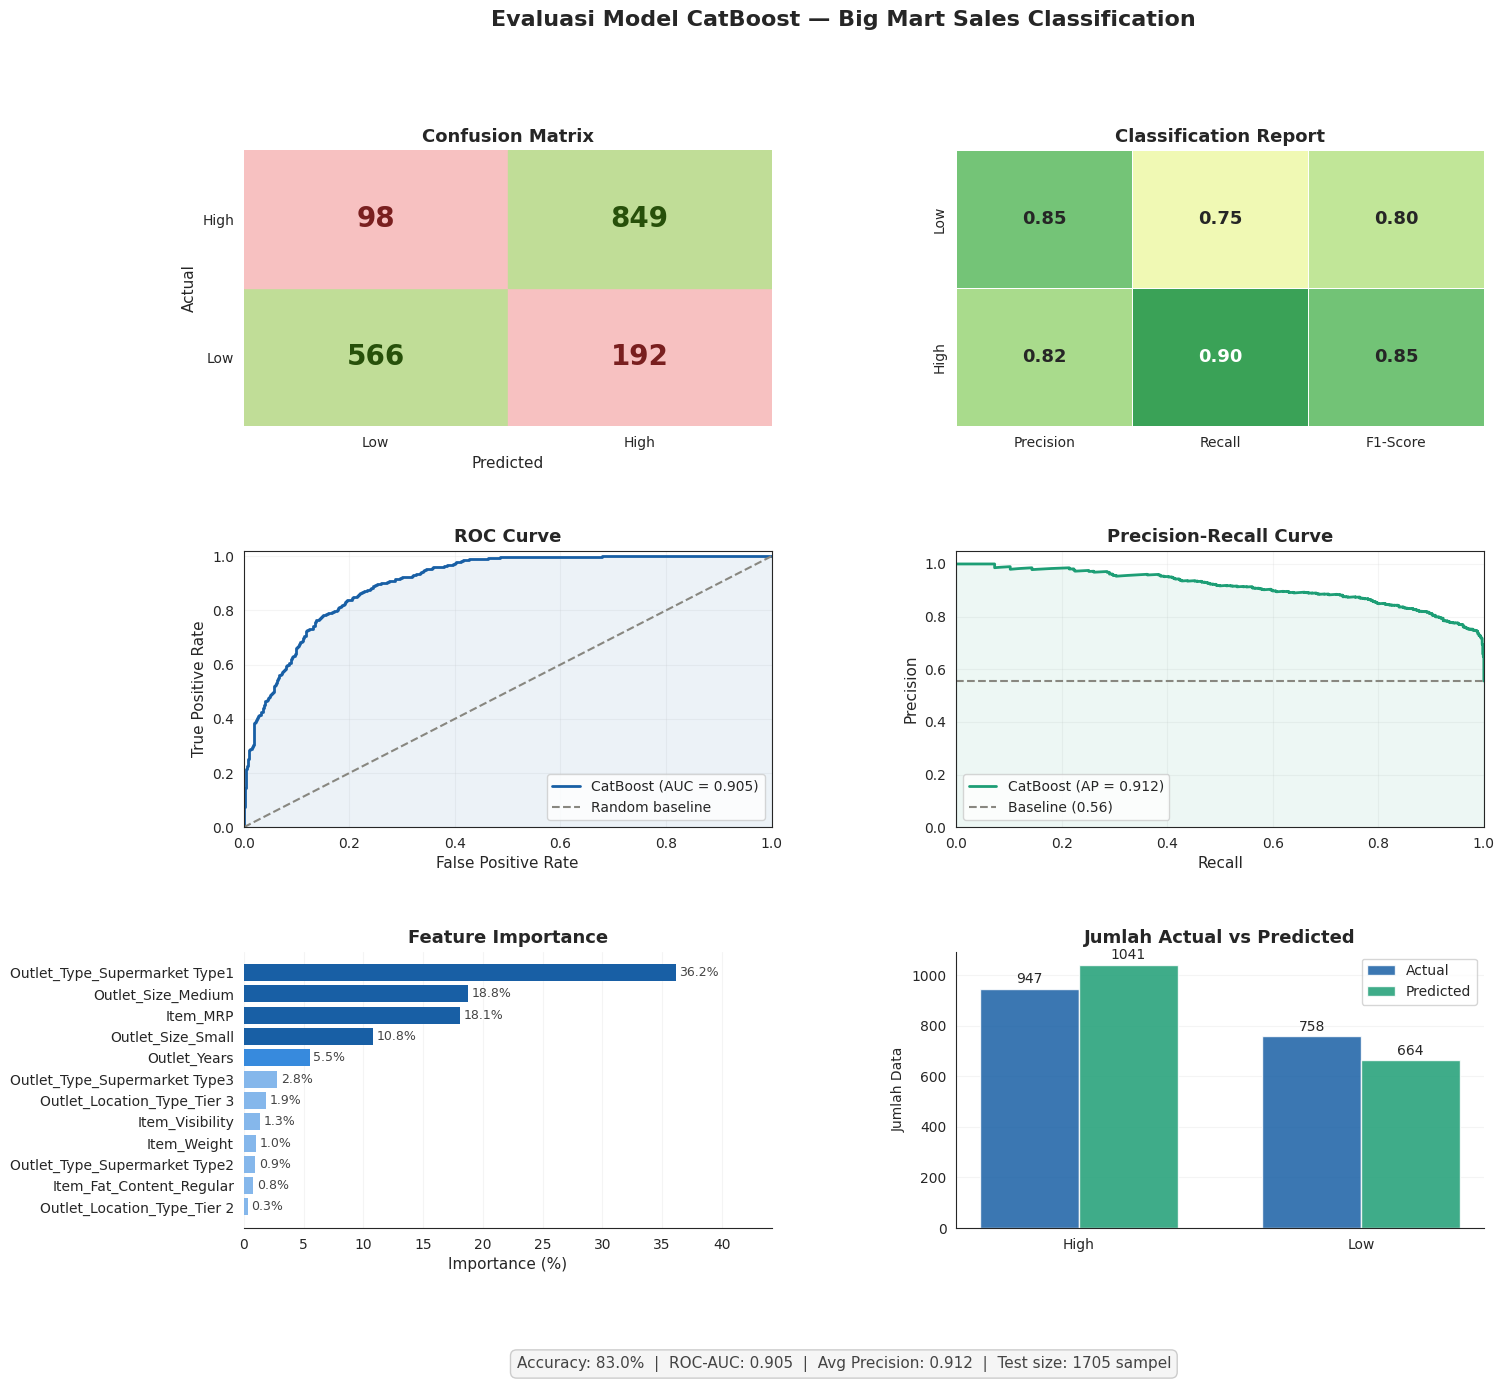

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# ── 1. Hitung Akurasi Baru dari cat_pred_custom ──────────────────────────────
acc_asli = (y_test == cat_pred_custom).mean()
print(f"Akurasi Terdeteksi dari cat_pred_custom: {acc_asli:.4f}")

# ── 2. Setup Integrasi Dataframe seperti Code Aslimu ──────────────────────────
df_result = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': cat_pred_custom
})
df_result['Status'] = df_result.apply(
    lambda r: 'Benar' if r['Actual'] == r['Predicted'] else 'Salah', axis=1
)

# ── 3. Setup Grid Visualisasi Besar ───────────────────────────────────────────
palette = {
    'blue_dark' : '#185FA5',
    'teal'      : '#1D9E75',
    'red_light' : '#F7C1C1',
    'green_light': '#C0DD97',
    'gray'      : '#888780',
}

fig = plt.figure(figsize=(16, 14))
fig.suptitle('Evaluasi Model CatBoost — Big Mart Sales Classification',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 8a. Confusion Matrix (Menggunakan cat_pred_custom) ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, cat_pred_custom, labels=['Low', 'High'])
cm_colors = np.array([
    [palette['green_light'], palette['red_light']],
    [palette['red_light'],   palette['green_light']]
])
for i in range(2):
    for j in range(2):
        ax1.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color=cm_colors[i][j], zorder=0))
        ax1.text(j, i, str(cm[i, j]), ha='center', va='center',
                 fontsize=20, fontweight='bold',
                 color='#27500A' if cm_colors[i][j] == palette['green_light'] else '#791F1F')
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Low', 'High']); ax1.set_yticklabels(['Low', 'High'])
ax1.set_xlabel('Predicted', fontsize=11); ax1.set_ylabel('Actual', fontsize=11)
ax1.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax1.set_xlim(-0.5, 1.5); ax1.set_ylim(-0.5, 1.5)
for spine in ax1.spines.values():
    spine.set_visible(False)

# ── 8b. Classification Report Heatmap (Menggunakan cat_pred_custom) ───────────
ax2 = fig.add_subplot(gs[0, 1])
cr_dict = classification_report(y_test, cat_pred_custom, labels=['Low', 'High'], output_dict=True)
cr_df = pd.DataFrame(cr_dict).T.loc[['Low', 'High'], ['precision', 'recall', 'f1-score']]
cr_df.columns = ['Precision', 'Recall', 'F1-Score']
sns.heatmap(cr_df.astype(float), annot=True, fmt='.2f', ax=ax2,
            cmap='YlGn', vmin=0.7, vmax=1.0, linewidths=0.5,
            annot_kws={'size': 13, 'weight': 'bold'}, cbar=False)
ax2.set_title('Classification Report', fontsize=13, fontweight='bold')
ax2.set_xlabel(''); ax2.set_ylabel('')

# ── 8c. ROC Curve ──────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(fpr, tpr, color=palette['blue_dark'], lw=2, label=f'CatBoost (AUC = {roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], color=palette['gray'], lw=1.5, linestyle='--', label='Random baseline')
ax3.fill_between(fpr, tpr, alpha=0.08, color=palette['blue_dark'])
ax3.set_xlabel('False Positive Rate', fontsize=11)
ax3.set_ylabel('True Positive Rate', fontsize=11)
ax3.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.set_xlim([0, 1]); ax3.set_ylim([0, 1.02])
ax3.grid(True, alpha=0.2)

# ── 8d. Precision-Recall Curve ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(recall, precision, color=palette['teal'], lw=2, label=f'CatBoost (AP = {avg_prec:.3f})')
baseline_ratio = (y_test == 'High').mean()
ax4.axhline(y=baseline_ratio, color=palette['gray'], lw=1.5, linestyle='--', label=f'Baseline ({baseline_ratio:.2f})')
ax4.fill_between(recall, precision, alpha=0.08, color=palette['teal'])
ax4.set_xlabel('Recall', fontsize=11)
ax4.set_ylabel('Precision', fontsize=11)
ax4.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
ax4.set_xlim([0, 1]); ax4.set_ylim([0, 1.05])
ax4.grid(True, alpha=0.2)

# ── 8e. Feature Importance ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
fi_df_top7 = fi_df.nlargest(12, 'Importance').sort_values('Importance')  # ambil top 7, sort ascending buat barh
colors_fi = [palette['blue_dark'] if v > 10 else '#378ADD' if v > 5 else '#85B7EB' for v in fi_df_top7['Importance']]
bars = ax5.barh(fi_df_top7['Feature'], fi_df_top7['Importance'], color=colors_fi, edgecolor='none')
for bar, val in zip(bars, fi_df_top7['Importance']):
    ax5.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontsize=9, color='#444')
ax5.set_xlabel('Importance (%)', fontsize=11)
ax5.set_title('Feature Importance', fontsize=13, fontweight='bold')
ax5.set_xlim(0, fi_df_top7['Importance'].max() + 8)
ax5.grid(True, axis='x', alpha=0.2)
ax5.spines[['top', 'right', 'left']].set_visible(False)

# ── 8f. Panel Kanan Bawah: Integrasi Logika Grafik Dua Kolom Milikmu ──────────
ax6 = fig.add_subplot(gs[2, 1])
actual_counts = df_result['Actual'].value_counts()
predicted_counts = pd.Series(cat_pred_custom).value_counts()

x_pos = np.arange(2)
width = 0.35
labels_bin = ['High', 'Low']

ax6.bar(x_pos - width/2, [actual_counts.get('High', 0), actual_counts.get('Low', 0)], width, label='Actual', color=palette['blue_dark'], alpha=0.85)
ax6.bar(x_pos + width/2, [predicted_counts.get('High', 0), predicted_counts.get('Low', 0)], width, label='Predicted', color=palette['teal'], alpha=0.85)

for i, (a, p) in enumerate(zip([actual_counts.get('High', 0), actual_counts.get('Low', 0)], [predicted_counts.get('High', 0), predicted_counts.get('Low', 0)])):
    ax6.text(i - width/2, a + 10, str(a), ha='center', va='bottom', fontsize=10)
    ax6.text(i + width/2, p + 10, str(p), ha='center', va='bottom', fontsize=10)

ax6.set_xticks(x_pos)
ax6.set_xticklabels(labels_bin)
ax6.set_title('Jumlah Actual vs Predicted', fontsize=13, fontweight='bold')
ax6.set_ylabel('Jumlah Data')
ax6.legend(fontsize=10)
ax6.grid(True, axis='y', alpha=0.2)
ax6.spines[['top', 'right']].set_visible(False)

# ── Summary text (Menggunakan nilai acc_asli) ──────────────a───────────────────
fig.text(0.5, 0.01,
         f'Accuracy: {acc_asli:.1%}  |  ROC-AUC: {roc_auc:.3f}  |  Avg Precision: {avg_prec:.3f}  |  Test size: {len(y_test)} sampel',
         ha='center', fontsize=11, color='#444',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5', edgecolor='#ccc'))

plt.savefig('evaluation_plots_fixed.png', dpi=150, bbox_inches='tight')

buf = BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
plt.show()
img_evaluation_plots_fixed_b64 = 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()

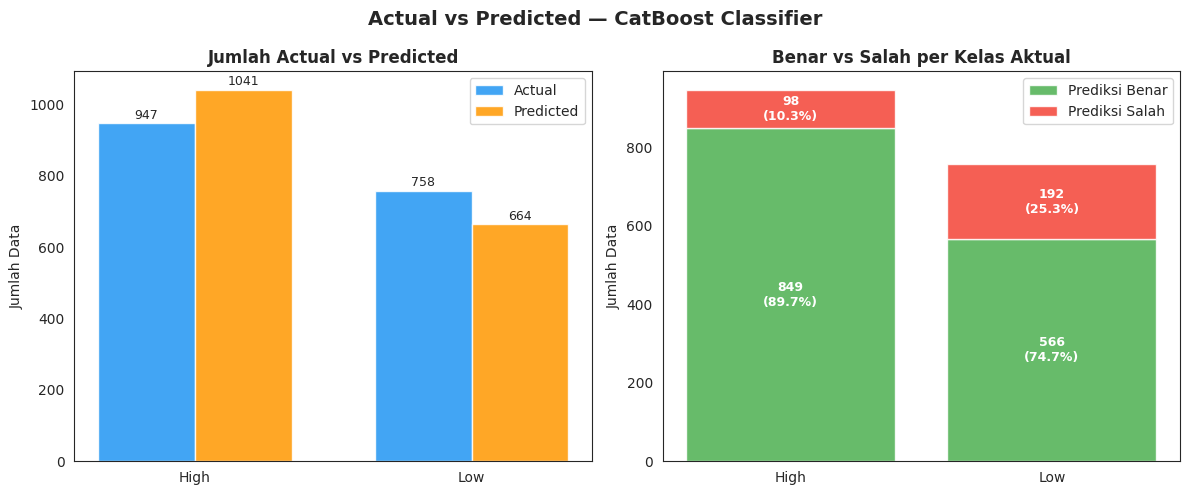

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── 1. Mengintegrasikan Dataframe Hasil Perbandingan Actual vs Predicted ──────
df_result = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': cat_pred_custom
})

# Menentukan status ketepatan prediksi tiap baris transaksi
df_result['Status'] = df_result.apply(
    lambda r: 'Benar' if r['Actual'] == r['Predicted'] else 'Salah', axis=1
)

# Inisialisasi kanvas visualisasi dengan format 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Actual vs Predicted — CatBoost Classifier', fontsize=14, fontweight='bold')

# ── 2. Panel 1: Grafik Distribusi Jumlah Actual vs Predicted ─────────────────
ax = axes[0]
actual_counts    = df_result['Actual'].value_counts()
predicted_counts = pd.Series(cat_pred_custom).value_counts()

x      = np.arange(2)
width  = 0.35
labels = ['High', 'Low']

# Plotting batang komparatif hulu-hilir
ax.bar(x - width/2, [actual_counts.get('High', 0), actual_counts.get('Low', 0)],
       width, label='Actual', color='#2196F3', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, [predicted_counts.get('High', 0), predicted_counts.get('Low', 0)],
       width, label='Predicted', color='#FF9800', alpha=0.85, edgecolor='white')

# Menampilkan label angka nominal di atas masing-masing batang
for i, (a, p) in enumerate(zip(
    [actual_counts.get('High', 0), actual_counts.get('Low', 0)],
    [predicted_counts.get('High', 0), predicted_counts.get('Low', 0)]
)):
    ax.text(i - width/2, a + 5, str(a), ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, p + 5, str(p), ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Jumlah Actual vs Predicted', fontweight='bold')
ax.set_ylabel('Jumlah Data')
ax.legend()

# ── 3. Panel 2: Grafik Proporsi Benar vs Salah per Kelas Aktual ──────────────
ax = axes[1]
summary = df_result.groupby(['Actual', 'Status']).size().unstack(fill_value=0)

benar = [summary.loc['High', 'Benar'] if 'Benar' in summary.columns else 0,
         summary.loc['Low',  'Benar'] if 'Benar' in summary.columns else 0]
salah = [summary.loc['High', 'Salah'] if 'Salah' in summary.columns else 0,
         summary.loc['Low',  'Salah'] if 'Salah' in summary.columns else 0]

# Plotting stacked bar chart untuk melihat rasio error per kelas
ax.bar(labels, benar, label='Prediksi Benar', color='#4CAF50', alpha=0.85, edgecolor='white')
ax.bar(labels, salah, bottom=benar, label='Prediksi Salah', color='#F44336', alpha=0.85, edgecolor='white')

# Menampilkan label persentase kontribusi performa di dalam batang
for i, (b, s) in enumerate(zip(benar, salah)):
    total = b + s
    ax.text(i, b / 2,        f'{b}\n({b/total*100:.1f}%)', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    ax.text(i, b + s / 2,    f'{s}\n({s/total*100:.1f}%)', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_title('Benar vs Salah per Kelas Aktual', fontweight='bold')
ax.set_ylabel('Jumlah Data')
ax.legend()

# ── 4. Finalisasi Kompilasi Grafik ───────────────────────────────────────────
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')

buf = BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
plt.show()
img_actual_vs_predicted_b64 = 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()

## **Deployment**

In [66]:
# export the model and related stuff
import json

# --- model export ---
best_cat_model.save_model(
    'model_pending.onnx',
    format='onnx',
    export_parameters={
        'onnx_domain': 'ai.catboost',
        'onnx_model_version': 1,
        'onnx_doc_string': 'Sales prediction model',
        'onnx_graph_name': 'SalesPredictionModel'
    }
)

# --- scaler export ---
scaler_params = {
    col: {"mean": float(m), "std": float(s)}
    for col, m, s in zip(X_train_encoded.columns, scaler.mean_, scaler.scale_)
}

categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
encoding_map = {}

for feat in categorical_features:
    matching_cols = [c for c in X_train_encoded.columns if c.startswith(f"{feat}_")]
    encoding_map[feat] = matching_cols

manifest = {
    "numerical_features": X_train.select_dtypes(exclude=['object']).columns.tolist(),
    "categorical_features": categorical_features,
    "encoding_map": encoding_map,
    "scaler": scaler_params,
    "all_encoded_columns": X_train_encoded.columns.tolist(),
    "threshold": 0.49
}

with open('model_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=4)

# --- schema export ---
schema = {
    "metadata": {
        "target": "Item_Outlet_Sales",
        "labels": ["Low", "High"],
        "threshold_used": 0.49
    },
    "features": {}
}

for col in X_train.columns:
    if X_train[col].dtype == 'object':
        schema["features"][col] = {
            "type": "categorical",
            "values": sorted(X_train[col].unique().tolist())
        }
    else:
        schema["features"][col] = {
            "type": "numeric",
            "min": float(X_train[col].min()),
            "max": float(X_train[col].max())
        }

schema["encoded_column_order"] = X_train_encoded.columns.tolist()

with open('model_schema.json', 'w') as f:
    json.dump(schema, f, indent=4)

# --- mappings export ---
label_mapping = {
    0: 'low_sales',
    1: 'high_sales'
}

with open('label_mapping.json', 'w') as f:
    json.dump(label_mapping, f)

In [67]:
# convert model to be compatible for the web

import onnx
from onnx import helper

model = onnx.load("model_pending.onnx")

zipmap_node = None
for node in model.graph.node:
    if node.op_type == 'ZipMap':
        zipmap_node = node
        break

if zipmap_node:
    raw_probs_name = zipmap_node.input[0]

    # remove the ZipMap for compatibility
    model.graph.node.remove(zipmap_node)

    # remove old mappings
    old_output = [obj for obj in model.graph.output if obj.name == "probabilities"][0]
    model.graph.output.remove(old_output)

    # create new mappings
    new_output = helper.make_tensor_value_info(
        name="probabilities",
        elem_type=onnx.TensorProto.FLOAT,
        shape=[None, 2]
    )

    # remap output
    for node in model.graph.node:
        for i, output_name in enumerate(node.output):
            if output_name == raw_probs_name:
                node.output[i] = "probabilities"

    model.graph.output.append(new_output)

    # export model
    onnx.save(model, "model.onnx")
    print("Clean model saved as model.onnx")
else:
    print("No ZipMap found. Your model might already be clean or exported differently.")

Clean model saved as model.onnx


In [68]:
# --- executive summary & charts for web dashboard ---
rows = []
rows.append('<table class="w-full text-xs border-collapse">')
rows.append('<tr><td class="font-semibold pt-2 pb-1" colspan="2">Dataset</td></tr>')
rows.append(f'<tr><td class="pl-2 py-0.5">Training samples</td><td class="text-right">{len(X_train)}</td></tr>')
rows.append(f'<tr><td class="pl-2 py-0.5">Test samples</td><td class="text-right">{len(X_test)}</td></tr>')
rows.append('<tr><td class="font-semibold pt-2 pb-1" colspan="2">Performance</td></tr>')
acc = accuracy_score(y_test, cat_pred_custom)
rows.append(f'<tr><td class="pl-2 py-0.5">Accuracy</td><td class="text-right">{acc:.4f}</td></tr>')
report_dict = classification_report(y_test, cat_pred_custom, output_dict=True)
for label in ['Low', 'High']:
    r = report_dict[label]
    rows.append(f'<tr><td class="pl-2 py-0.5">{label} — Precision</td><td class="text-right">{r["precision"]:.4f}</td></tr>')
    rows.append(f'<tr><td class="pl-2 py-0.5">{label} — Recall</td><td class="text-right">{r["recall"]:.4f}</td></tr>')
    rows.append(f'<tr><td class="pl-2 py-0.5">{label} — F1</td><td class="text-right">{r["f1-score"]:.4f}</td></tr>')
rows.append('<tr><td class="font-semibold pt-2 pb-1" colspan="2">Top 10 Features</td></tr>')
imp = best_cat_model.get_feature_importance()
cols = X_train_encoded.columns.tolist()
for idx in np.argsort(imp)[::-1][:10]:
    rows.append(f'<tr><td class="pl-2 py-0.5 truncate max-w-[180px]">{cols[idx]}</td><td class="text-right">{imp[idx]:.4f}</td></tr>')
rows.append('</table>')
rows.append('<p class="text-xs mt-2">Custom threshold: <strong>0.49</strong>. Adjust if business needs change.</p>')
executive_summary_html = '\n'.join(rows)

In [69]:
# embed the model and related data into the web dashboard export

import base64
import json
import os
import sys

ROOT = "./"

def read(path):
    with open(os.path.join(ROOT, path)) as f:
        return f.read()

def read_b64(path):
    with open(os.path.join(ROOT, path), 'rb') as f:
        return base64.b64encode(f.read()).decode()

html = read('template.html')
schema = read('model_schema.json')
manifest = read('model_manifest.json')
model_b64 = read_b64('model.onnx')

html = html.replace('__SCHEMA__', schema)
html = html.replace('__MANIFEST__', manifest)
html = html.replace('__MODEL_B64__', model_b64)
html = html.replace('__EXECUTIVE_SUMMARY__', executive_summary_html)

html = html.replace('__UNIVARIATE_NUM__', img_check_univariate_num_b64)
html = html.replace('__HISTPLOT_SALES__', img_histplot_item_outlet_sales_b64)
html = html.replace('__BOXPLOT_SALES__', img_boxplot_item_outlet_sales_b64)
html = html.replace('__MRP_VS_SALES__', img_mrp_vs_sales_b64)
html = html.replace('__CORR_MATRIX__', img_correlation_matrix_b64)
html = html.replace('__CONFUSION_MATRIX__', img_confusion_matrix_sales_category_b64)
html = html.replace('__EVALUATION_PLOTS__', img_evaluation_plots_fixed_b64)
html = html.replace('__ACTUAL_VS_PREDICTED__', img_actual_vs_predicted_b64)

#os.makedirs(os.path.join(ROOT, 'dist'), exist_ok=True)
out_path = os.path.join(ROOT, 'dashboard.html')
with open(out_path, 'w') as f:
    f.write(html)

size_kb = len(html) / 1024
print(f'Built dist/index.html ({size_kb:.0f} KB)')
print(f'  schema.json   → inlined as _SCHEMA')
print(f'  manifest.json → inlined as _MANIFEST')
print(f'  model.onnx    → inlined as _MODEL_B64 ({len(model_b64) / 1024:.0f} KB base64)')


Built dist/index.html (1628 KB)
  schema.json   → inlined as _SCHEMA
  manifest.json → inlined as _MANIFEST
  model.onnx    → inlined as _MODEL_B64 (697 KB base64)
